In [3]:
from google.colab import files
import pandas as pd
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import re
import holidays
import numpy as np

# Block 1: Understanding Your Problem & Data

We’re predicting how many parking spots will be free soon in each parkade, our target is y_avail_t+H, which equals total Stalls minus the number of cars we expect to be parked then. To make that prediction, we use  signals that matter in real life: the lot’s size and how full it is now (occ), the time of day and whether it’s a weekday or weekend (because parking follows routines), recent activity over the last hours/days (to capture momentum), visitor habits like how long since a plate’s last visit and total visits (regulars often repeat patterns), and typical stay length (duration_hours) to estimate when spaces free up. We also add holiday/event flags (is_holiday) since demand often changes on those days.

# Block 2: Creating Time-Based Features

In [4]:
parking_df= pd.read_csv('merged_clean.csv')

In [5]:
parking_df.head()

,ID,Installation,Type,Source type,Unit,Zone,Fee,Plate,Collection GUID,Date,...,End date (UTC),Status date (UTC),Ticket Number,Coupon Amount,Number of Coupons,Hope Insertion Date,Hope Gps Latitude,Hope Gps Longitude,Unit_clean,weekday
0,153654800,Banff,Parking,External,Unknown,Downtown,Regular Rate,0EV050,NaN,2025-08-17 19:59:00,...,2025-08-18 02:00:00,2025-08-18 01:59:00,NaN,NaN,NaN,2025-08-17 19:59:00,51.17718,-115.57108,Unknown,Sunday
1,153654791,Banff,Parking,Internal,BANFF15- CLOCK TOWER LOT,Downtown,Regular Rate,CPZ2037,5058fd818dbfc0e28091660dba1574738cd509a9febe6e6c,2025-08-17 19:53:00,...,2025-08-18 02:00:00,2025-08-18 01:55:00,102312.0,$-,0.0,2025-08-17 19:54:00,51.17476,-115.56962,CLOCK TOWER LOT,Sunday
2,153654789,Banff,Extension,Internal,BANFF05- CLOCK TOWER LOT WEST,Downtown,Residents Rate,BSK6477,255c4f59fd1da869f1658cdfcae3cf171c5b3eb854f64221,2025-08-17 19:54:00,...,2025-08-18 02:00:00,2025-08-18 01:54:00,5518.0,$-,0.0,2025-08-17 19:54:00,51.17476,-115.56979,CLOCK TOWER LOT WEST,Sunday
3,153654785,Banff,Parking,Internal,BANFF18- TOWN HALL LOT,Downtown,Regular Rate,0CN343,25e4a70085dc0bb3811275faef39f28785ee2935cddfc393,2025-08-17 19:53:00,...,2025-08-18 02:00:00,2025-08-18 01:53:00,86840.0,$-,0.0,2025-08-17 19:53:00,51.17532,-115.57248,TOWN HALL LOT,Sunday
4,153654783,Banff,Extension,Internal,BANFF04- MARTEN 300 BLOCK,Downtown,Regular Rate,PL803P,34e51775d45d64864e7d842e1bb2efd0c334721a89a1cd51,2025-08-17 19:51:00,...,2025-08-18 15:00:00,2025-08-18 01:53:00,15948.0,$-,0.0,2025-08-17 19:53:00,51.18085,-115.57057,MARTEN 300 BLOCK,Sunday


In [6]:

#find period for the dataset
# 1) Make sure they're datetimes
cols = ['Starting date', 'End date']
parking_df[cols] = parking_df[cols].apply(pd.to_datetime, errors='coerce')

# 2) Per-column min/max
start_min = parking_df['Starting date'].min()
start_max = parking_df['Starting date'].max()
end_min   = parking_df['End date'].min()
end_max   = parking_df['End date'].max()

print("Starting date  -> earliest:", start_min, " latest:", start_max)
print("End date       -> earliest:", end_min,   " latest:", end_max)

# 3) Overall dataset coverage (min across both cols, max across both cols)
overall_min = pd.concat([parking_df['Starting date'], parking_df['End date']]).min()
overall_max = pd.concat([parking_df['Starting date'], parking_df['End date']]).max()
print("\nDataset coverage:", overall_min, "to", overall_max)

# 4)  show the rows where these extremes occur
if parking_df['Starting date'].notna().any():
    print("\nRow with earliest Starting date:")
    print(parking_df.loc[parking_df['Starting date'].idxmin(), cols])

if parking_df['End date'].notna().any():
    print("\nRow with latest End date:")
    print(parking_df.loc[parking_df['End date'].idxmax(), cols])


Starting date  -> earliest: 2025-08-04 08:00:00  latest: 2025-08-31 20:00:00
End date       -> earliest: 2025-08-04 08:30:00  latest: 2025-09-01 09:00:00

Dataset coverage: 2025-08-04 08:00:00 to 2025-09-01 09:00:00

Row with earliest Starting date:
Starting date    2025-08-04 08:00:00
End date         2025-08-04 10:00:00
Name: 39235, dtype: object

Row with latest End date:
Starting date    2025-08-31 20:00:00
End date         2025-09-01 09:00:00
Name: 58283, dtype: object


In [7]:

#Calculate Parking Duration from Starting date and End date
# Convert both columns to datetime format (handles strings or mixed formats)
parking_df['Starting date'] = pd.to_datetime(parking_df['Starting date'], errors='coerce')
parking_df['End date'] = pd.to_datetime(parking_df['End date'], errors='coerce')

# Calculate raw duration as a timedelta
parking_df['Duration'] = parking_df['End date'] - parking_df['Starting date']

# Extract duration in numeric units

parking_df['Duration_minutes'] = parking_df['Duration'].dt.total_seconds() / 60

#  Optional: Round values for readability

parking_df['Duration_minutes'] = parking_df['Duration_minutes'].round(1)

#  Preview the results
print(parking_df[['Starting date', 'End date', 'Duration_minutes']].head())


        Starting date            End date  Duration_minutes
0 2025-08-17 19:59:00 2025-08-17 20:00:00               1.0
1 2025-08-17 19:53:00 2025-08-17 20:00:00               7.0
2 2025-08-17 19:54:00 2025-08-17 20:00:00               6.0
3 2025-08-17 19:53:00 2025-08-17 20:00:00               7.0
4 2025-08-17 20:00:00 2025-08-18 09:00:00             780.0


In [8]:
# Use Starting date as your main reference
parking_df['year'] = parking_df['Starting date'].dt.year
parking_df['month'] = parking_df['Starting date'].dt.month
parking_df['day'] = parking_df['Starting date'].dt.day
parking_df['weekday'] = parking_df['Starting date'].dt.day_name()
parking_df['hour'] = parking_df['Starting date'].dt.hour
parking_df['weekofyear'] = parking_df['Starting date'].dt.isocalendar().week.astype(int)

# Weekend flag (helps detect higher weekend demand)
parking_df['is_weekend'] = parking_df['Starting date'].dt.dayofweek.isin([5, 6]).astype(int)

# Duration of parking
parking_df['duration_hours'] = (parking_df['End date'] - parking_df['Starting date']).dt.total_seconds() / 3600
parking_df['duration_hours'] = parking_df['duration_hours'].round(2)


In [9]:
#add a simple holiday flag
# Define Canadian holidays
canada_holidays = holidays.Canada()

# Create boolean flag directly (no need for astype conversions)
parking_df['is_holiday'] = parking_df['Starting date'].dt.date.isin(canada_holidays).astype(int)


In [10]:
#Link each ticket’s Unit text to a clean Parkade name and its Stalls (capacity)
# by extracting the BANFF code from  Unit strings and mapping that code to the correct lot metadata.
# --- 1) Normalize and extract the BANFF code from Unit / Unit_key ---
def norm(s):
    if pd.isna(s): return np.nan
    s = str(s).replace('\u00A0',' ').strip()        # NBSP -> space, trim
    s = re.sub(r'\s+', ' ', s)                      # collapse spaces
    return s

parking_df['Unit_key'] = parking_df.get('Unit_key', parking_df['Unit']).apply(norm)

# Extract BANFF code like BANFF24 from "BANFF24- CENTRAL PARK LOT SOUTH"
parking_df['Unit_code'] = parking_df['Unit_key'].str.extract(r'(BANFF\d+)', expand=False)

# --- 2) Code -> (Parkade, Stalls) mapping (fill/extend as you learn more) ---
code_to_parkade = {
    'BANFF17': 'Central Park',
    'BANFF24': 'Central Park',
    'BANFF01': 'Health Unit',
    'BANFF11': 'Bear Street',
    'BANFF28': 'Bear Street Parkade',
    'BANFF27': 'Bear Street Parkade',
    'BANFF19': 'Bear Street Parkade',
    'BANFF18': 'Town Hall',
    'BANFF25': 'Town Hall',
    'BANFF05': 'Clock Tower Lot',
    'BANFF14': 'Mount Royal',
    'BANFF13': 'Mount Royal',
    'BANFF08': 'Fire Hall',
    'BANFF26': 'Fire Hall',
    'BANFF09': 'Fire Hall'
}

code_to_stalls = {
    'BANFF17': 74,  'BANFF24': 74,          # Central Park
    'BANFF01': 23,                          # Health Unit
    'BANFF11': 44,                          # Bear Street
    'BANFF28': 215, 'BANFF27': 215, 'BANFF19': 215,  # Bear Street Parkade
    'BANFF18': 27,  'BANFF25': 27,          # Town Hall
    'BANFF05': 46,                          # Clock Tower Lot
    'BANFF14': 25,  'BANFF13': 25,          # Mount Royal
    'BANFF08': 78,  'BANFF26': 78,  'BANFF09': 78,   # Fire Hall
    # fill when known:
    # 'BANFF12': <stalls_for_caribou_masons>,
}

# --- 3) Map to new columns ---
parking_df['Parkade'] = parking_df['Unit_code'].map(code_to_parkade)
parking_df['Stalls']  = parking_df['Unit_code'].map(code_to_stalls)

# If you had existing Parkade/Stalls, only fill missing:
# parking_df['Parkade'] = parking_df['Parkade'].fillna(parking_df['Unit_code'].map(code_to_parkade))
# parking_df['Stalls']  = parking_df['Stalls'].fillna(parking_df['Unit_code'].map(code_to_stalls))

# --- 4) See what didn’t match so you can extend the mapping ---
unmatched = (parking_df.loc[parking_df['Parkade'].isna(), 'Unit_key']
             .dropna().sort_values().unique())
print("Unmatched Unit strings (add their codes to the mapping):")
for u in unmatched[:50]:
    print(" -", u)

missing_codes = (parking_df.loc[parking_df['Parkade'].isna(), 'Unit_code']
                 .dropna().unique())
print("\nUnmapped BANFF codes:", missing_codes)


Unmatched Unit strings (add their codes to the mapping):
 - BANFF02- WOLF AT MARTEN
 - BANFF03- PLAZA PARKADE
 - BANFF04- MARTEN 300 BLOCK
 - BANFF06- ELK STREET IGA
 - BANFF07- WOLF HIGH SCHOOL
 - BANFF10- CARIBOU FIRE HALL
 - BANFF12- CARIBOU MASONS
 - BANFF15- CLOCK TOWER LOT
 - BANFF16- BUFFALO AND BANFF
 - BANFF20- LYNX 100 BLOCK
 - BANFF21- LYNX 200 BLOCK
 - BANFF22- WOLF AT ALLEY
 - BANFF23- WOLF 300 SOUTH
 - Unknown

Unmapped BANFF codes: ['BANFF15' 'BANFF04' 'BANFF23' 'BANFF12' 'BANFF10' 'BANFF21' 'BANFF16'
 'BANFF20' 'BANFF22' 'BANFF06' 'BANFF02' 'BANFF03' 'BANFF07']


# Block 3: Traffic-Based Features

In [11]:
# Total Number of Visits per vehicle
parking_df['total_visits'] = parking_df.groupby('Plate')['Plate'].transform('count')


In [12]:
#Captures long-term loyalty — how long they’ve been using the service.
first_visit = parking_df.groupby('Plate')['Starting date'].transform('min')
parking_df['days_since_first_visit'] = (parking_df['Starting date'] - first_visit).dt.days


In [13]:
#Days Since Last Visit
prev_visit = parking_df.groupby('Plate')['Starting date'].shift(1)
parking_df['days_since_last_visit'] = (parking_df['Starting date'] - prev_visit).dt.days


In [14]:
#This code creates recency features per vehicle (Plate)—i.e., how long it’s been since that plate’s previous visit
# 1) ensure proper datetime (UTC columns)
parking_df['Starting date (UTC)'] = pd.to_datetime(parking_df['Starting date (UTC)'], errors='coerce', utc=True)
parking_df['End date (UTC)']      = pd.to_datetime(parking_df['End date (UTC)'], errors='coerce', utc=True)

# 2) sort within each Plate by start time
parking_df = parking_df.sort_values(['Plate', 'Starting date (UTC)'])

# 3) previous start per Plate
prev_start = parking_df.groupby('Plate')['Starting date (UTC)'].shift(1)

# 4) time since last visit (as Timedelta)
gap = parking_df['Starting date (UTC)'] - prev_start

# 5) optional: treat out-of-order rows (negative gaps) as missing instead of -1
gap = gap.where(gap >= pd.Timedelta(0), pd.NaT)

# 6) choose your unit
parking_df['days_since_last_visit']  = gap / pd.Timedelta(days=1)        # fractional days
parking_df['hours_since_last_visit'] = gap / pd.Timedelta(hours=1)       # hours
parking_df['mins_since_last_visit']  = gap / pd.Timedelta(minutes=1)     # minutes

# If you really want integer days without negatives:
parking_df['days_since_last_visit_int'] = np.floor(parking_df['days_since_last_visit']).astype('Int64')

In [15]:
# Build the modeling target for short-term parking:
#   - Compute current occupancy per Parkade over time
#   - Create future occupancy (y_occ_t+H)
#   - Create future availability (y_avail_t+H) = Stalls - y_occ_t+H

CADENCE = '15min'
H_STEPS = 4  # forecast horizon (4 * 15min = 60 min) CADENCE = '15min': we want a time grid every 15 minutes.

#H_STEPS = 4: predict 4 steps ahead → 4×15min = 60 minutes into the future.

# 1) Prep
df = parking_df[['Parkade','Stalls','Starting date','End date']].copy()
df['Starting date'] = pd.to_datetime(df['Starting date'], errors='coerce')
df['End date']      = pd.to_datetime(df['End date'], errors='coerce')

# 2) Build events (+1 at start, -1 at end)
starts = df[['Parkade','Starting date']].rename(columns={'Starting date':'ts'})
starts['delta'] = 1
ends   = df[['Parkade','End date']].rename(columns={'End date':'ts'})
ends['delta']  = -1
events = pd.concat([starts, ends], ignore_index=True).dropna(subset=['ts'])

# 3) AGGREGATE events to ensure unique (Parkade, ts)
events_agg = (events
              .groupby(['Parkade','ts'], as_index=False)['delta']
              .sum())

# 4) Cumulative sum -> occupancy timeline (ts unique now)
occ = (events_agg
       .sort_values(['Parkade','ts'])
       .groupby('Parkade')
       .apply(lambda g: g.set_index('ts')['delta'].cumsum())
       .rename('occ')
       .reset_index())

# 5) Regular time grid + forward fill
occ = (occ.set_index('ts')
          .groupby('Parkade', group_keys=False)
          .apply(lambda s: s.resample(CADENCE).ffill())
          .fillna(0)
          .reset_index()
          .rename(columns={'ts':'timestamp'}))

# 6) Bring capacity and create targets
cap = df[['Parkade','Stalls']].dropna().drop_duplicates('Parkade')
occ = occ.merge(cap, on='Parkade', how='left')

occ['occ_next_60min']   = occ.groupby('Parkade')['occ'].shift(-H_STEPS)
occ['avail_next_60min'] = occ['Stalls'] - occ['occ_next_60min']   # TARGET

print(occ.head())


            timestamp      Parkade  occ  Stalls  occ_next_60min  \
0 2025-08-04 08:00:00            0  0.0     NaN             0.0   
1 2025-08-04 08:15:00  Bear Street  1.0    44.0             9.0   
2 2025-08-04 08:30:00  Bear Street  2.0    44.0             8.0   
3 2025-08-04 08:45:00  Bear Street  3.0    44.0             8.0   
4 2025-08-04 09:00:00  Bear Street  8.0    44.0             9.0   

   avail_next_60min  
0               NaN  
1              35.0  
2              36.0  
3              36.0  
4              35.0  


/tmp/ipython-input-207512126.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.set_index('ts')['delta'].cumsum())
/tmp/ipython-input-207512126.py:39: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda s: s.resample(CADENCE).ffill())


'occ_next_60min' = occupancy 60 minutes in the future (shifted up by 4 steps).

'avail_next_60min' = future available stalls = capacity − future occupancy.

In [16]:
CADENCE = '15min'

# make a grid-aligned timestamp in parking_df (based on Starting date)
parking_df['timestamp'] = pd.to_datetime(parking_df['Starting date'], errors='coerce').dt.floor(CADENCE)

# merge targets from occ
parking_df = parking_df.merge(
    occ[['Parkade','timestamp','occ','occ_next_60min','avail_next_60min']],
    on=['Parkade','timestamp'],
    how='left'
)


# Block 5: Understanding Feature Relationships (Correlation Analysis & Visualization)

Top correlations with target:
Stalls                    0.927302
occ                       0.238914
total_visits              0.028416
Time                     -0.027422
is_weekend               -0.027216
days_since_first_visit    0.026964
days_since_last_visit     0.025784
hours_since_last_visit    0.025784
Amount                   -0.023602
duration_hours           -0.022309
hour                      0.016775
day                      -0.006664
Online                   -0.003974
weekofyear               -0.002655
Name: avail_next_60min, dtype: float64


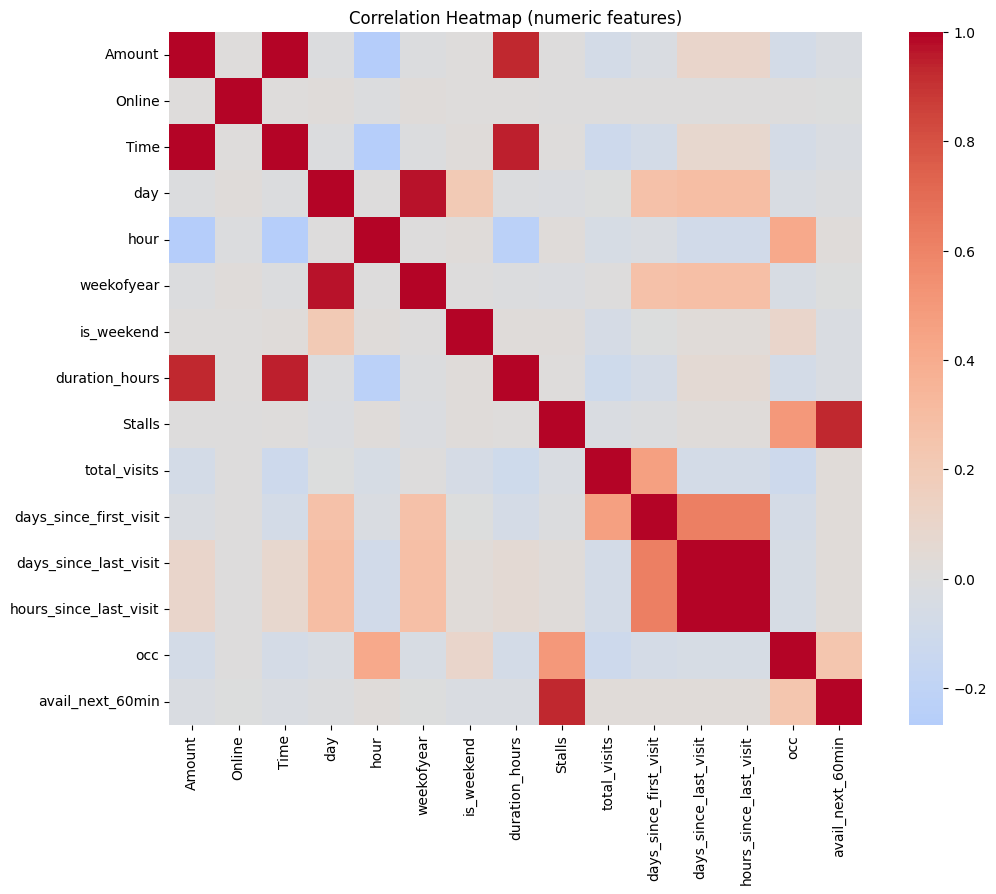

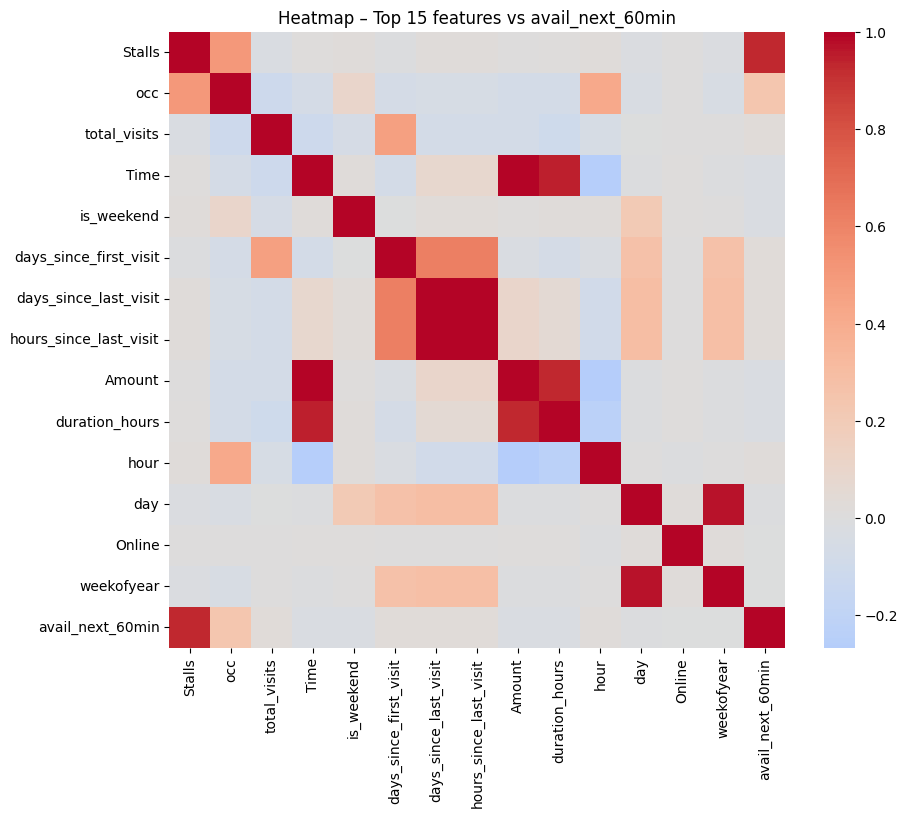

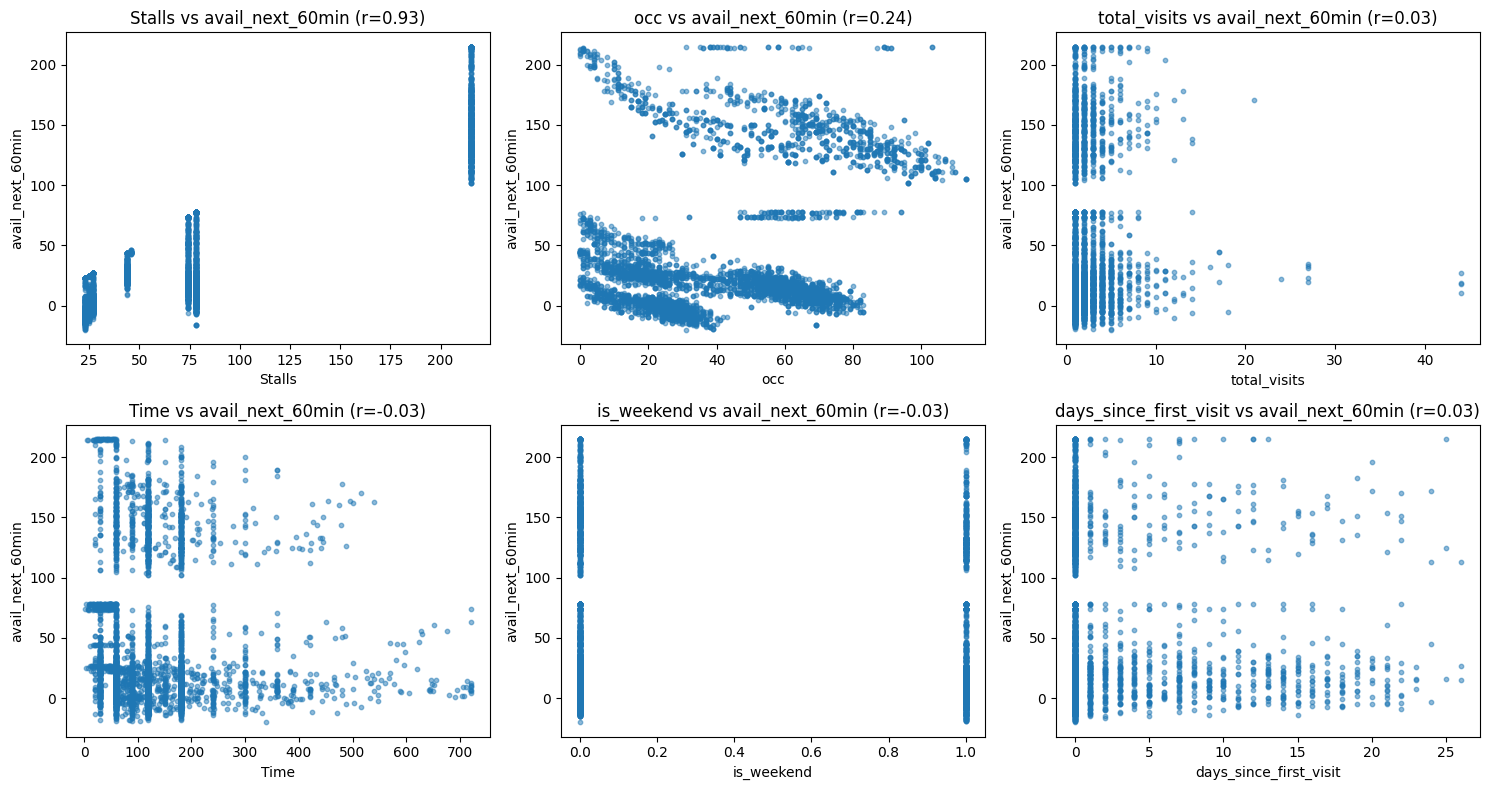

Weak vs avail_next_60min (|r|<0.05): ['total_visits', 'Time', 'is_weekend', 'days_since_first_visit', 'days_since_last_visit', 'hours_since_last_visit', 'Amount', 'duration_hours', 'hour', 'day', 'Online', 'weekofyear']
Highly collinear to drop (>|0.9|): []
Final feature count: 4
Predictors: ['Duration', 'Stalls', 'occ']


In [17]:

TARGET = 'avail_next_60min'   #or 'occ_next_60min'

# 0) Numeric frame + drop junk/targets/duplicates
drop_cols = [
    'ID', 'Ticket Number',
    'Hope Gps Latitude', 'Hope Gps Longitude',
    'Duration_minutes',              # keep duration_hours
    'mins_since_last_visit',         # keep hours_since_last_visit
    'days_since_last_visit_int',
    'PT1 amount', 'PT1 changed value', 'Amount with bonification', 'Bonification',
    # targets
    'occ_next_60min', 'avail_next_60min'
]
Z = parking_df.select_dtypes(include=[np.number]).drop(columns=[c for c in drop_cols if c in parking_df.columns], errors='ignore')

# Reattach the target separately (must be numeric)
if TARGET not in parking_df.columns:
    raise KeyError(f"Target '{TARGET}' not found in parking_df.")
Z[TARGET] = pd.to_numeric(parking_df[TARGET], errors='coerce')

# Drop zero-variance columns
const_cols = [c for c in Z.columns if Z[c].nunique(dropna=True) <= 1]
Z.drop(columns=const_cols, inplace=True, errors='ignore')

# 1) Correlation matrix (+ correlations to target)
corr = Z.corr(numeric_only=True)
corr_to_t = corr[TARGET].drop(index=TARGET).sort_values(key=lambda s: s.abs(), ascending=False)
print("Top correlations with target:")
print(corr_to_t.head(20))

# 2) Heatmaps
# 2a) full numeric heatmap (without IDs/targets already removed)
plt.figure(figsize=(12, 9))
sns.heatmap(corr, cmap='coolwarm', center=0, square=True, cbar=True)
plt.title("Correlation Heatmap (numeric features)")
plt.show()

# 2b) focused heatmap on top-k vs target
topk = 15
top_feats = corr_to_t.head(topk).index.tolist() + [TARGET]
plt.figure(figsize=(10, 8))
sns.heatmap(Z[top_feats].corr(), cmap='coolwarm', center=0, square=True)
plt.title(f"Heatmap – Top {topk} features vs {TARGET}")
plt.show()

# 3) Scatter plots (visual check) for top N features
N = 6
feat_list = corr_to_t.head(N).index.tolist()
rows = int(np.ceil(N/3))
plt.figure(figsize=(15, 4*rows))
for i, f in enumerate(feat_list, 1):
    ax = plt.subplot(rows, 3, i)
    sample = Z[[f, TARGET]].dropna()
    if len(sample) > 5000:
        sample = sample.sample(5000, random_state=42)
    ax.scatter(sample[f], sample[TARGET], s=10, alpha=0.5)
    ax.set_xlabel(f); ax.set_ylabel(TARGET)
    ax.set_title(f"{f} vs {TARGET} (r={corr.loc[f, TARGET]:.2f})")
plt.tight_layout(); plt.show()

# 4) Feature selection helpers
# 4a) prune weak vs target
weak_thr = 0.05
weak_feats = corr_to_t[ corr_to_t.abs() < weak_thr ].index.tolist()
print(f"Weak vs {TARGET} (|r|<{weak_thr}):", weak_feats)
X_weak_pruned = Z.drop(columns=weak_feats)

# 4b) remove multicollinearity among predictors
mc_thr = 0.90
C = X_weak_pruned.drop(columns=[TARGET]).corr().abs()
upper = C.where(np.triu(np.ones(C.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > mc_thr)]
print(f"Highly collinear to drop (>|{mc_thr}|):", to_drop)

X_final = X_weak_pruned.drop(columns=to_drop)
print("Final feature count:", X_final.shape[1])

# Optional: list of final predictors you’ll feed to the model
predictors = [c for c in X_final.columns if c != TARGET]
print("Predictors:", predictors)


In [18]:
parking_df.head()

,ID,Installation,Type,Source type,Unit,Zone,Fee,Plate,Collection GUID,Date,...,total_visits,days_since_first_visit,days_since_last_visit,hours_since_last_visit,mins_since_last_visit,days_since_last_visit_int,timestamp,occ,occ_next_60min,avail_next_60min
0,154472622,Banff,Parking,Internal,BANFF24- CENTRAL PARK LOT SOUTH,Downtown,Regular Rate,0000CD,a0781701c35ebf2187c3e177f68c449f66e70beea87136f0,2025-08-31 08:55:00,...,1,0,NaN,NaN,NaN,<NA>,2025-08-31 08:45:00,5.0,23.0,51.0
1,154463807,Banff,Parking,External,Unknown,Downtown,Regular Rate,0003ALE,NaN,2025-08-30 17:48:00,...,1,0,NaN,NaN,NaN,<NA>,2025-08-30 17:45:00,NaN,NaN,NaN
2,154199839,Banff,Parking,External,Unknown,Downtown,Regular Rate,0006370,NaN,2025-08-26 18:25:00,...,1,0,NaN,NaN,NaN,<NA>,2025-08-26 18:15:00,NaN,NaN,NaN
3,154267897,Banff,Parking,External,Unknown,Downtown,Regular Rate,000786,NaN,2025-08-27 17:05:00,...,1,0,NaN,NaN,NaN,<NA>,2025-08-27 17:00:00,NaN,NaN,NaN
4,154230753,Banff,Parking,External,Unknown,Downtown,Regular Rate,00094A,NaN,2025-08-27 10:34:00,...,1,0,NaN,NaN,NaN,<NA>,2025-08-27 10:30:00,NaN,NaN,NaN


In [19]:
# Save the merged data
parking_df.to_csv("parking_feature_clean.csv", index=False)

from google.colab import files
files.download("parking_feature_clean.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

We’re teaching a model to answer a simple question—how many parking spaces will be free soon. Our main target is y_avail_t+H (future availability): at time t, predict how many spaces will be free at time t+H (e.g., in 60 minutes). We compute it as Stalls − y_occ_t+H, where y_occ_t+H is our alternative target: the future occupancy (how many cars will be parked at t+H). To make this prediction accurate, we give the model common-sense signals like time of day, weekend/holiday, how full the lot is right now (occ), recent activity over the last hours/days, typical stay length, and how often the same vehicles return

In [20]:
import pandas as pd
import numpy as np

In [21]:
# Read the cleaned merged dataset
df_clean = pd.read_csv("merged_clean.csv")

#Block 1: **Understanding the Problem & Data**

Problem Statement:
Our goal is to predict short-term parking availability in Banff’s public parking lots. The target variable is the number of cars parked in each lot per hour, which makes this a regression problem. Accurate prediction can help visitors and city planners understand occupancy trends and manage parking resources efficiently.

Internal Features (from dataset):

**hour_of_day**: Captures the daily cycle of parking demand (morning, lunch, evening peaks).

**day_of_week**: Captures weekly patterns, e.g., weekends vs weekdays.

entry_volume_hour: Total vehicles across all lots per hour, showing general demand trends.

entry_volume_lot_hour: Vehicles per lot per hour, capturing lot-specific busy periods.

rolling_avg_occupancy: Smoothed occupancy trend over the past 4 hours for each lot, helping the model learn recent trends rather than isolated spikes.

Unit_clean: Parking lot identifier, which allows the model to differentiate between lots with different capacities or popularity.

In [22]:
df_clean.columns

Index(['ID', 'Installation', 'Type', 'Source type', 'Unit', 'Zone', 'Fee',
       'Plate', 'Collection GUID', 'Date', 'Starting date', 'End date',
       'Payment type', 'PT1 amount', 'PT1 change applied', 'PT1 changed value',
       'Amount', 'Amount with bonification', 'Bonification', 'Online', 'Time',
       'Status', 'Insertion date (UTC)', 'Refunded ID', 'UTC Date',
       'Starting date (UTC)', 'End date (UTC)', 'Status date (UTC)',
       'Ticket Number', 'Coupon Amount', 'Number of Coupons',
       'Hope Insertion Date', 'Hope Gps Latitude', 'Hope Gps Longitude',
       'Unit_clean', 'weekday'],
      dtype='object')

In [23]:
df_clean.head()

,ID,Installation,Type,Source type,Unit,Zone,Fee,Plate,Collection GUID,Date,...,End date (UTC),Status date (UTC),Ticket Number,Coupon Amount,Number of Coupons,Hope Insertion Date,Hope Gps Latitude,Hope Gps Longitude,Unit_clean,weekday
0,153654800,Banff,Parking,External,Unknown,Downtown,Regular Rate,0EV050,NaN,2025-08-17 19:59:00,...,2025-08-18 02:00:00,2025-08-18 01:59:00,NaN,NaN,NaN,2025-08-17 19:59:00,51.17718,-115.57108,Unknown,Sunday
1,153654791,Banff,Parking,Internal,BANFF15- CLOCK TOWER LOT,Downtown,Regular Rate,CPZ2037,5058fd818dbfc0e28091660dba1574738cd509a9febe6e6c,2025-08-17 19:53:00,...,2025-08-18 02:00:00,2025-08-18 01:55:00,102312.0,$-,0.0,2025-08-17 19:54:00,51.17476,-115.56962,CLOCK TOWER LOT,Sunday
2,153654789,Banff,Extension,Internal,BANFF05- CLOCK TOWER LOT WEST,Downtown,Residents Rate,BSK6477,255c4f59fd1da869f1658cdfcae3cf171c5b3eb854f64221,2025-08-17 19:54:00,...,2025-08-18 02:00:00,2025-08-18 01:54:00,5518.0,$-,0.0,2025-08-17 19:54:00,51.17476,-115.56979,CLOCK TOWER LOT WEST,Sunday
3,153654785,Banff,Parking,Internal,BANFF18- TOWN HALL LOT,Downtown,Regular Rate,0CN343,25e4a70085dc0bb3811275faef39f28785ee2935cddfc393,2025-08-17 19:53:00,...,2025-08-18 02:00:00,2025-08-18 01:53:00,86840.0,$-,0.0,2025-08-17 19:53:00,51.17532,-115.57248,TOWN HALL LOT,Sunday
4,153654783,Banff,Extension,Internal,BANFF04- MARTEN 300 BLOCK,Downtown,Regular Rate,PL803P,34e51775d45d64864e7d842e1bb2efd0c334721a89a1cd51,2025-08-17 19:51:00,...,2025-08-18 15:00:00,2025-08-18 01:53:00,15948.0,$-,0.0,2025-08-17 19:53:00,51.18085,-115.57057,MARTEN 300 BLOCK,Sunday


In [24]:
date_cols = [
    'Starting date', 'End date', 'Date', 'Insertion date (UTC)',
    'UTC Date', 'Starting date (UTC)', 'End date (UTC)',
    'Status date (UTC)', 'Hope Insertion Date'
]


In [25]:
for col in date_cols:
    if col in df_clean.columns:
        df_clean[col] = pd.to_datetime(df_clean[col], errors='coerce')


In [26]:
df_clean[date_cols].dtypes


,0
Starting date,datetime64[ns]
End date,datetime64[ns]
Date,datetime64[ns]
Insertion date (UTC),datetime64[ns]
UTC Date,datetime64[ns]
Starting date (UTC),datetime64[ns]
End date (UTC),datetime64[ns]
Status date (UTC),datetime64[ns]
Hope Insertion Date,datetime64[ns]


hour_of_day
Numeric (0–23)
Extracted from Starting date
Captures daily cycles; helps model morning, lunch, evening peak hours

In [27]:
# Already created
df_clean['hour_of_day'] = df_clean['Starting date'].dt.hour
df_clean[['Starting date','hour_of_day']].head()


,Starting date,hour_of_day
0,2025-08-17 19:59:00,19
1,2025-08-17 19:53:00,19
2,2025-08-17 19:54:00,19
3,2025-08-17 19:53:00,19
4,2025-08-17 20:00:00,20


In [28]:
# Count total cars per hour (all lots combined)
hourly_counts = df_clean.groupby('hour_of_day').size().reset_index(name='entry_volume_hour')
hourly_counts


,hour_of_day,entry_volume_hour
0,8,2794
1,9,3514
2,10,5808
3,11,8195
4,12,8159
5,13,7975
6,14,7917
7,15,7441
8,16,7385
9,17,7229


In [29]:
# Peak hour
peak_hour = hourly_counts.loc[hourly_counts['entry_volume_hour'].idxmax()]
print(f"Peak hour overall: {peak_hour['hour_of_day']} with {peak_hour['entry_volume_hour']} cars")

# Off-peak hour
offpeak_hour = hourly_counts.loc[hourly_counts['entry_volume_hour'].idxmin()]
print(f"Off-peak hour overall: {offpeak_hour['hour_of_day']} with {offpeak_hour['entry_volume_hour']} cars")



Peak hour overall: 11 with 8195 cars
Off-peak hour overall: 20 with 137 cars


In [30]:
df_clean = df_clean.merge(hourly_counts, on='hour_of_day', how='left')
df_clean[['hour_of_day','entry_volume_hour']].head(10)

,hour_of_day,entry_volume_hour
0,19,4406
1,19,4406
2,19,4406
3,19,4406
4,20,137
5,19,4406
6,19,4406
7,19,4406
8,19,4406
9,19,4406


entry_volume_lot_hour
Numeric
Cars parked per lot per hour
Captures lot-specific demand; helps identify which lot is busy at each hour

In [31]:
# Count cars per parking lot per hour
lot_hourly_counts = df_clean.groupby(['Unit_clean', 'hour_of_day']).size().reset_index(name='entry_volume_lot_hour')

# Check result
lot_hourly_counts.head(15)


,Unit_clean,hour_of_day,entry_volume_lot_hour
0,BEAR PARKADE L1,8,4
1,BEAR PARKADE L1,9,9
2,BEAR PARKADE L1,10,32
3,BEAR PARKADE L1,11,109
4,BEAR PARKADE L1,12,222
5,BEAR PARKADE L1,13,227
6,BEAR PARKADE L1,14,230
7,BEAR PARKADE L1,15,171
8,BEAR PARKADE L1,16,132
9,BEAR PARKADE L1,17,110


In [32]:
df_clean = df_clean.merge(lot_hourly_counts, on=['Unit_clean','hour_of_day'], how='left')

# Check first few rows
df_clean[['Unit_clean','hour_of_day','entry_volume_lot_hour']].head(10)


,Unit_clean,hour_of_day,entry_volume_lot_hour
0,Unknown,19,1600
1,CLOCK TOWER LOT,19,209
2,CLOCK TOWER LOT WEST,19,30
3,TOWN HALL LOT,19,169
4,MARTEN 300 BLOCK,20,2
5,TOWN HALL LOT,19,169
6,BEAR PARKADE L2,19,132
7,CLOCK TOWER LOT WEST,19,30
8,CENTRAL PARK LOT,19,276
9,"FIRE HALL LOT 1 ""WEST""",19,229


In [33]:
df_clean.head(20)

,ID,Installation,Type,Source type,Unit,Zone,Fee,Plate,Collection GUID,Date,...,Coupon Amount,Number of Coupons,Hope Insertion Date,Hope Gps Latitude,Hope Gps Longitude,Unit_clean,weekday,hour_of_day,entry_volume_hour,entry_volume_lot_hour
0,153654800,Banff,Parking,External,Unknown,Downtown,Regular Rate,0EV050,NaN,2025-08-17 19:59:00,...,NaN,NaN,2025-08-17 19:59:00,51.17718,-115.57108,Unknown,Sunday,19,4406,1600
1,153654791,Banff,Parking,Internal,BANFF15- CLOCK TOWER LOT,Downtown,Regular Rate,CPZ2037,5058fd818dbfc0e28091660dba1574738cd509a9febe6e6c,2025-08-17 19:53:00,...,$-,0.0,2025-08-17 19:54:00,51.17476,-115.56962,CLOCK TOWER LOT,Sunday,19,4406,209
2,153654789,Banff,Extension,Internal,BANFF05- CLOCK TOWER LOT WEST,Downtown,Residents Rate,BSK6477,255c4f59fd1da869f1658cdfcae3cf171c5b3eb854f64221,2025-08-17 19:54:00,...,$-,0.0,2025-08-17 19:54:00,51.17476,-115.56979,CLOCK TOWER LOT WEST,Sunday,19,4406,30
3,153654785,Banff,Parking,Internal,BANFF18- TOWN HALL LOT,Downtown,Regular Rate,0CN343,25e4a70085dc0bb3811275faef39f28785ee2935cddfc393,2025-08-17 19:53:00,...,$-,0.0,2025-08-17 19:53:00,51.17532,-115.57248,TOWN HALL LOT,Sunday,19,4406,169
4,153654783,Banff,Extension,Internal,BANFF04- MARTEN 300 BLOCK,Downtown,Regular Rate,PL803P,34e51775d45d64864e7d842e1bb2efd0c334721a89a1cd51,2025-08-17 19:51:00,...,$-,0.0,2025-08-17 19:53:00,51.18085,-115.57057,MARTEN 300 BLOCK,Sunday,20,137,2
5,153654781,Banff,Parking,Internal,BANFF18- TOWN HALL LOT,Downtown,Regular Rate,0CW205,25e4a70085dc0bb3811275faef39f28785ee2935cddfc393,2025-08-17 19:51:00,...,$-,0.0,2025-08-17 19:52:00,51.17532,-115.57248,TOWN HALL LOT,Sunday,19,4406,169
6,153654775,Banff,Parking,External,BANFF28- BEAR PARKADE L2,Downtown,Regular Rate,K23536,NaN,2025-08-17 19:51:00,...,NaN,NaN,2025-08-17 19:52:00,51.17620,-115.57262,BEAR PARKADE L2,Sunday,19,4406,132
7,153654762,Banff,Parking,Internal,BANFF05- CLOCK TOWER LOT WEST,Downtown,Regular Rate,OCK570,255c4f59fd1da869f1658cdfcae3cf171c5b3eb854f64221,2025-08-17 19:47:00,...,$-,0.0,2025-08-17 19:48:00,51.17476,-115.56979,CLOCK TOWER LOT WEST,Sunday,19,4406,30
8,153654756,Banff,Parking,Internal,BANFF17- CENTRAL PARK LOT,Downtown,Regular Rate,A06511,21fc0e015cc31b7e22d947f84aec3ff5161535e9e5c1fdf9,2025-08-17 19:46:00,...,$-,0.0,2025-08-17 19:47:00,51.17442,-115.57277,CENTRAL PARK LOT,Sunday,19,4406,276
9,153654753,Banff,Parking,Internal,"BANFF08- FIRE HALL LOT 1 ""WEST""",Downtown,Regular Rate,CPK4652,a65d06f9ace88d62d3ed72fbbe82619c81830042f11ffe48,2025-08-17 19:46:00,...,$-,0.0,2025-08-17 19:46:00,51.17720,-115.56995,"FIRE HALL LOT 1 ""WEST""",Sunday,19,4406,229


day_of_week
Categorical (Mon–Sun)
Extracted from Starting date
Captures weekly patterns; some days (weekends) are busier

In [34]:
# Create day_of_week feature
df_clean['day_of_week'] = df_clean['Starting date'].dt.day_name()
df_clean[['Starting date','day_of_week']].head()


,Starting date,day_of_week
0,2025-08-17 19:59:00,Sunday
1,2025-08-17 19:53:00,Sunday
2,2025-08-17 19:54:00,Sunday
3,2025-08-17 19:53:00,Sunday
4,2025-08-17 20:00:00,Sunday


In [35]:
# Total cars parked per day of week
weekday_counts = df_clean.groupby('day_of_week').size().reset_index(name='entry_volume_day')
weekday_counts


,day_of_week,entry_volume_day
0,Friday,10852
1,Monday,11070
2,Saturday,11551
3,Sunday,11395
4,Thursday,10896
5,Tuesday,10864
6,Wednesday,10978


In [36]:
# Merge total entries per day back to main dataframe
df_clean = df_clean.merge(weekday_counts, on='day_of_week', how='left', suffixes=('','_day'))
df_clean[['day_of_week','entry_volume_day']].head(10)


,day_of_week,entry_volume_day
0,Sunday,11395
1,Sunday,11395
2,Sunday,11395
3,Sunday,11395
4,Sunday,11395
5,Sunday,11395
6,Sunday,11395
7,Sunday,11395
8,Sunday,11395
9,Sunday,11395


In [37]:
df_clean.head()

,ID,Installation,Type,Source type,Unit,Zone,Fee,Plate,Collection GUID,Date,...,Hope Insertion Date,Hope Gps Latitude,Hope Gps Longitude,Unit_clean,weekday,hour_of_day,entry_volume_hour,entry_volume_lot_hour,day_of_week,entry_volume_day
0,153654800,Banff,Parking,External,Unknown,Downtown,Regular Rate,0EV050,NaN,2025-08-17 19:59:00,...,2025-08-17 19:59:00,51.17718,-115.57108,Unknown,Sunday,19,4406,1600,Sunday,11395
1,153654791,Banff,Parking,Internal,BANFF15- CLOCK TOWER LOT,Downtown,Regular Rate,CPZ2037,5058fd818dbfc0e28091660dba1574738cd509a9febe6e6c,2025-08-17 19:53:00,...,2025-08-17 19:54:00,51.17476,-115.56962,CLOCK TOWER LOT,Sunday,19,4406,209,Sunday,11395
2,153654789,Banff,Extension,Internal,BANFF05- CLOCK TOWER LOT WEST,Downtown,Residents Rate,BSK6477,255c4f59fd1da869f1658cdfcae3cf171c5b3eb854f64221,2025-08-17 19:54:00,...,2025-08-17 19:54:00,51.17476,-115.56979,CLOCK TOWER LOT WEST,Sunday,19,4406,30,Sunday,11395
3,153654785,Banff,Parking,Internal,BANFF18- TOWN HALL LOT,Downtown,Regular Rate,0CN343,25e4a70085dc0bb3811275faef39f28785ee2935cddfc393,2025-08-17 19:53:00,...,2025-08-17 19:53:00,51.17532,-115.57248,TOWN HALL LOT,Sunday,19,4406,169,Sunday,11395
4,153654783,Banff,Extension,Internal,BANFF04- MARTEN 300 BLOCK,Downtown,Regular Rate,PL803P,34e51775d45d64864e7d842e1bb2efd0c334721a89a1cd51,2025-08-17 19:51:00,...,2025-08-17 19:53:00,51.18085,-115.57057,MARTEN 300 BLOCK,Sunday,20,137,2,Sunday,11395


In [38]:
df_clean.columns

Index(['ID', 'Installation', 'Type', 'Source type', 'Unit', 'Zone', 'Fee',
       'Plate', 'Collection GUID', 'Date', 'Starting date', 'End date',
       'Payment type', 'PT1 amount', 'PT1 change applied', 'PT1 changed value',
       'Amount', 'Amount with bonification', 'Bonification', 'Online', 'Time',
       'Status', 'Insertion date (UTC)', 'Refunded ID', 'UTC Date',
       'Starting date (UTC)', 'End date (UTC)', 'Status date (UTC)',
       'Ticket Number', 'Coupon Amount', 'Number of Coupons',
       'Hope Insertion Date', 'Hope Gps Latitude', 'Hope Gps Longitude',
       'Unit_clean', 'weekday', 'hour_of_day', 'entry_volume_hour',
       'entry_volume_lot_hour', 'day_of_week', 'entry_volume_day'],
      dtype='object')

#rolling_avg_occupancy

9 AM:9 cars parked in BEAR PARKADE L1
Rolling average = 9 → only previous hours included (here probably just 9 AM itself, since rolling window includes fewer than 4 hours at the start)

10 AM: 32 cars parked
Rolling average = 20.5 → this includes 9 AM (9 cars) + 10 AM (32 cars), averaged over the rolling window

11 AM:109 cars parked
Rolling average gradually increases (51 → 70 → 89 → 109) because each new hour adds to the previous 4-hour window

12 PM:222 cars parked
Rolling average = 137.2 → the 4-hour window smooths the jump, reflecting recent trend rather than the raw spike

In [39]:
df_clean = df_clean.sort_values(['Unit_clean','Starting date'])


In [40]:
df_clean['rolling_avg_occupancy'] = df_clean.groupby('Unit_clean')['entry_volume_lot_hour']\
                                           .transform(lambda x: x.rolling(4, min_periods=1).mean())


In [41]:
df_clean[['Unit_clean','hour_of_day','entry_volume_lot_hour','rolling_avg_occupancy']].head(10)


,Unit_clean,hour_of_day,entry_volume_lot_hour,rolling_avg_occupancy
39023,BEAR PARKADE L1,9,9,9.000000
38906,BEAR PARKADE L1,10,32,20.500000
38887,BEAR PARKADE L1,10,32,24.333333
38874,BEAR PARKADE L1,10,32,26.250000
38498,BEAR PARKADE L1,11,109,51.250000
38484,BEAR PARKADE L1,11,109,70.500000
38466,BEAR PARKADE L1,11,109,89.750000
38459,BEAR PARKADE L1,11,109,109.000000
38445,BEAR PARKADE L1,11,109,109.000000
38432,BEAR PARKADE L1,12,222,137.250000


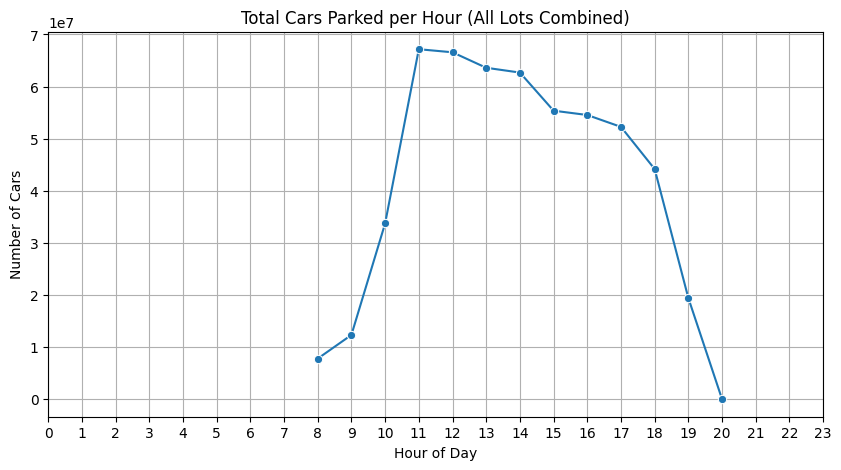

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df_clean is your dataframe with all engineered features

# --- 1️⃣ Hour of the Day Insights ---
plt.figure(figsize=(10,5))
sns.lineplot(data=df_clean.groupby('hour_of_day')['entry_volume_hour'].sum().reset_index(),
             x='hour_of_day', y='entry_volume_hour', marker='o')
plt.title('Total Cars Parked per Hour (All Lots Combined)')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Cars')
plt.xticks(range(0,24))
plt.grid(True)
plt.show()

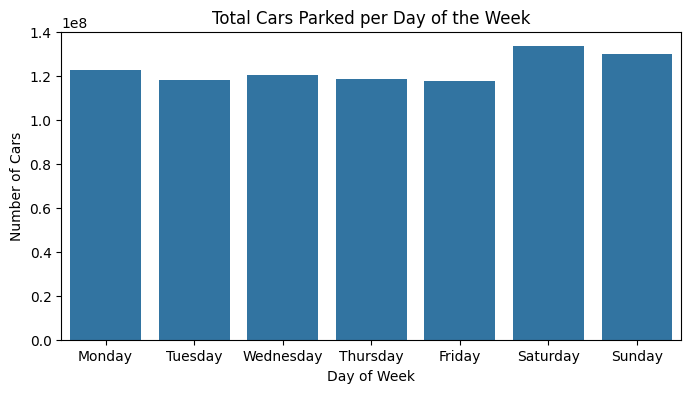

In [43]:
plt.figure(figsize=(8,4))
sns.barplot(data=df_clean.groupby('day_of_week')['entry_volume_day'].sum().reset_index(),
            x='day_of_week', y='entry_volume_day', order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
plt.title('Total Cars Parked per Day of the Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Cars')
plt.show()

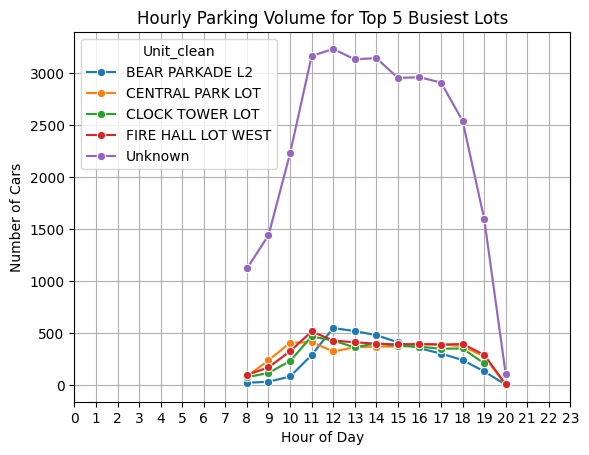

In [44]:
top_lots = df_clean.groupby('Unit_clean')['entry_volume_lot_hour'].sum().sort_values(ascending=False).head(5).index
sns.lineplot(data=df_clean[df_clean['Unit_clean'].isin(top_lots)],
             x='hour_of_day', y='entry_volume_lot_hour', hue='Unit_clean', marker='o')
plt.title('Hourly Parking Volume for Top 5 Busiest Lots')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Cars')
plt.xticks(range(0,24))
plt.grid(True)
plt.show()

Peak Hour: 11 AM is the critical congestion point—ideal for scheduling interventions or dynamic pricing.

Low-Usage Window: 0–6 AM could be leveraged for maintenance or discounted rates.

Rolling Average: Smooths short-term fluctuations, useful for trend detection but may obscure sharp transitions.

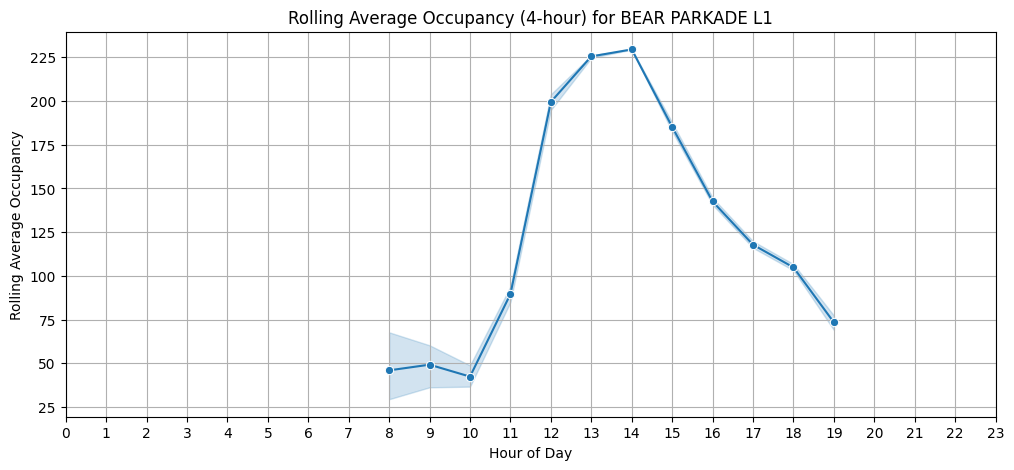

In [45]:
plt.figure(figsize=(12,5))
sns.lineplot(data=df_clean[df_clean['Unit_clean']=='BEAR PARKADE L1'],
             x='hour_of_day', y='rolling_avg_occupancy', marker='o')
plt.title('Rolling Average Occupancy (4-hour) for BEAR PARKADE L1')
plt.xlabel('Hour of Day')
plt.ylabel('Rolling Average Occupancy')
plt.xticks(range(0,24))
plt.grid(True)
plt.show()

In [46]:
# Create binary flag for weekend
df_clean['is_weekend'] = df_clean['day_of_week'].isin(['Saturday', 'Sunday']).astype(int)

# Check
df_clean[['day_of_week', 'is_weekend']].head(10)


,day_of_week,is_weekend
39023,Monday,0
38906,Monday,0
38887,Monday,0
38874,Monday,0
38498,Monday,0
38484,Monday,0
38466,Monday,0
38459,Monday,0
38445,Monday,0
38432,Monday,0


In [47]:
weekend_volume = df_clean.groupby('is_weekend')['entry_volume_day'].sum().reset_index()
print("Total Parking Volume on Weekdays vs Weekends:")
print(weekend_volume)

Total Parking Volume on Weekdays vs Weekends:
   is_weekend  entry_volume_day
0           0         597576600
1           1         263271626


In [48]:
# Calculate parking duration in minutes
df_clean['parking_duration_min'] = ((df_clean['End date'] - df_clean['Starting date']).dt.total_seconds() / 60).round(2)


# Quick look
df_clean[['Plate', 'Starting date', 'End date', 'parking_duration_min']].head()


,Plate,Starting date,End date,parking_duration_min
39023,CNS2842,2025-08-04 09:53:00,2025-08-04 12:53:00,180.0
38906,BZF6494,2025-08-04 10:32:00,2025-08-04 12:32:00,120.0
38887,0FE877,2025-08-04 10:37:00,2025-08-04 12:37:00,120.0
38874,CSC7787,2025-08-04 10:40:00,2025-08-04 13:40:00,180.0
38498,J33102,2025-08-04 11:52:00,2025-08-04 14:52:00,180.0


In [49]:
df_clean.head()

,ID,Installation,Type,Source type,Unit,Zone,Fee,Plate,Collection GUID,Date,...,Unit_clean,weekday,hour_of_day,entry_volume_hour,entry_volume_lot_hour,day_of_week,entry_volume_day,rolling_avg_occupancy,is_weekend,parking_duration_min
39023,152862017,Banff,Parking,Internal,BANFF27- BEAR PARKADE L1,Downtown,Regular Rate,CNS2842,ab3c5a4cfd3e32edd8b5a28e6bdb00413fb52d06e6ac2847,2025-08-04 09:53:00,...,BEAR PARKADE L1,Monday,9,3514,9,Monday,11070,9.000000,0,180.0
38906,152865354,Banff,Parking,Internal,BANFF27- BEAR PARKADE L1,Downtown,Regular Rate,BZF6494,ab3c5a4cfd3e32edd8b5a28e6bdb00413fb52d06e6ac2847,2025-08-04 10:32:00,...,BEAR PARKADE L1,Monday,10,5808,32,Monday,11070,20.500000,0,120.0
38887,152865895,Banff,Parking,Internal,BANFF27- BEAR PARKADE L1,Downtown,Regular Rate,0FE877,ab3c5a4cfd3e32edd8b5a28e6bdb00413fb52d06e6ac2847,2025-08-04 10:37:00,...,BEAR PARKADE L1,Monday,10,5808,32,Monday,11070,24.333333,0,120.0
38874,152866156,Banff,Parking,Internal,BANFF27- BEAR PARKADE L1,Downtown,Regular Rate,CSC7787,ab3c5a4cfd3e32edd8b5a28e6bdb00413fb52d06e6ac2847,2025-08-04 10:40:00,...,BEAR PARKADE L1,Monday,10,5808,32,Monday,11070,26.250000,0,180.0
38498,152872861,Banff,Parking,Internal,BANFF27- BEAR PARKADE L1,Downtown,Regular Rate,J33102,ab3c5a4cfd3e32edd8b5a28e6bdb00413fb52d06e6ac2847,2025-08-04 11:52:00,...,BEAR PARKADE L1,Monday,11,8195,109,Monday,11070,51.250000,0,180.0


In [50]:
df_clean.to_csv("parking_features.csv", index=False)
